## Assignment 2: $k$ Nearest Neighbor

### Do any four.

In [2]:
! git clone https://github.com/ds4e/get_data
%run ./get_data/get_data.py

Cloning into 'get_data'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 115 (delta 40), reused 31 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (115/115), 1.73 MiB | 7.42 MiB/s, done.
Resolving deltas: 100% (53/53), done.
Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Answers:

1. Regression is when you are trying to predict a numeric value, and classification is when you are trying to predict a categorical value.

2. A confusion table compares true values with the predicted values. It helps you understand how well the model is predicting values

3. Accuracy tells you what portion of predicted values were correct. It might not be sufficient if the classes are not balanced. The accuracy may seem right but only predicts the majority class well and does not predict the minority class well.

4. The root mean squared error shows the distance between the true value and the predicted value

5. If a k is too low, then there is more variance and more sensitive to the data points. This is overfitting. When k is too high, the model will give results closer to the mean and will not consider enough variance. This is underfitting.

6. By splitting the data into training and testing sets and using RMSE, it helps you identify the best k value for new data.

7. For class label, it tells us the predicted category which is simple and straightforward. The weakness to it is that we do not know how confident the prediction is or the potential alternatives. That is the strength of probability distribution over class labels. We can see the confidence for each class label. The issue is intrepreting these confidence levels.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Part 1

In [3]:
import pandas as pd

mine = pd.read_csv('/content/data/land_mines.csv', encoding='latin1')
mine.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


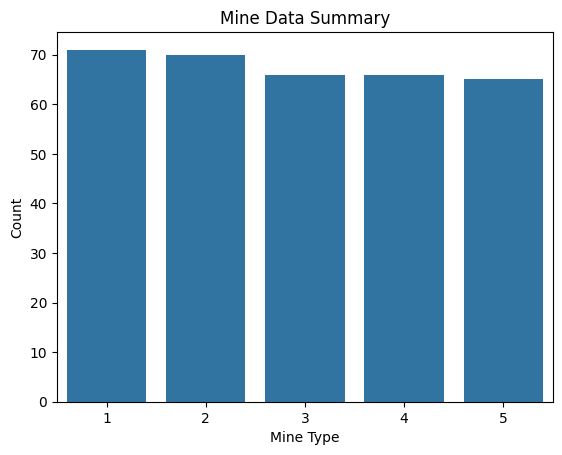

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='mine_type', data=mine)
plt.title("Mine Data Summary")
plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.show()


In [5]:
mine[['voltage', 'height', 'soil']].describe()

,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


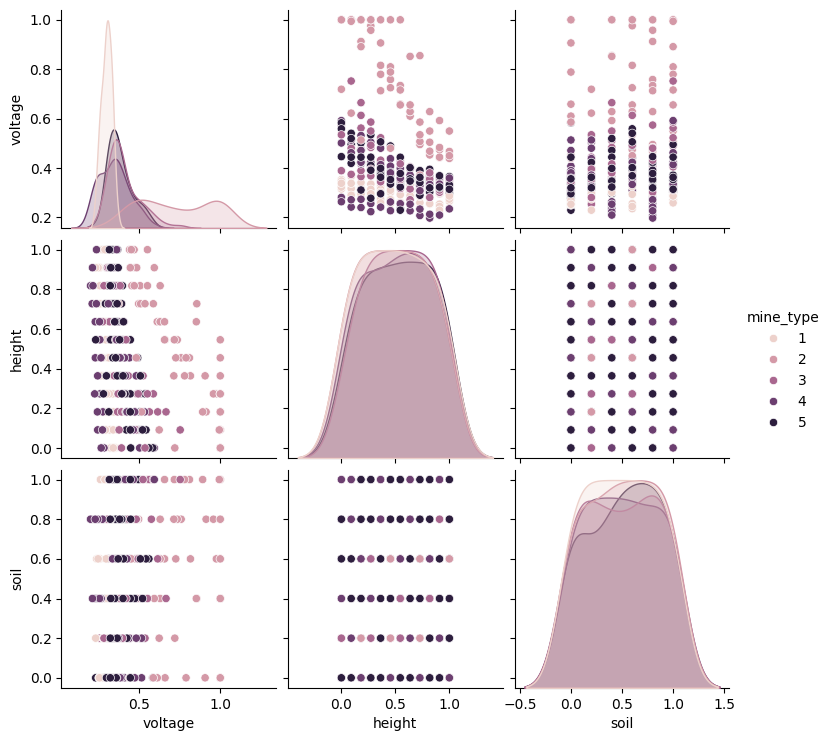

In [6]:
sns.pairplot(mine, hue='mine_type')
plt.show()

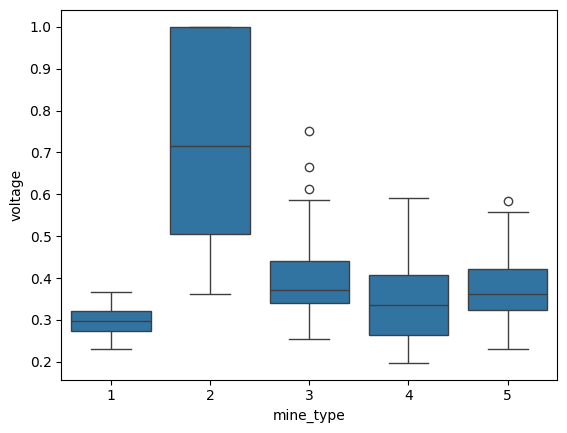

In [7]:
sns.boxplot(x='mine_type', y='voltage', data=mine)
plt.show()

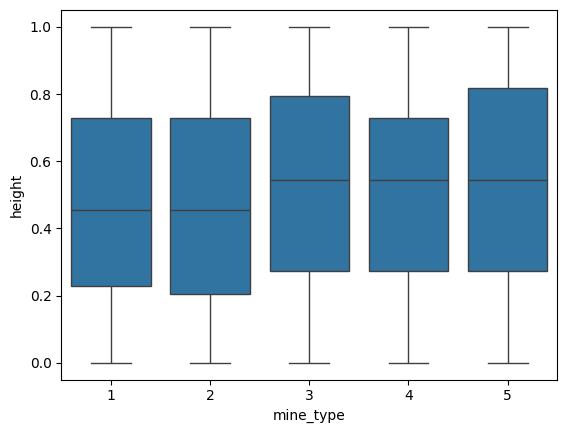

In [8]:
sns.boxplot(x='mine_type', y='height', data=mine)
plt.show()

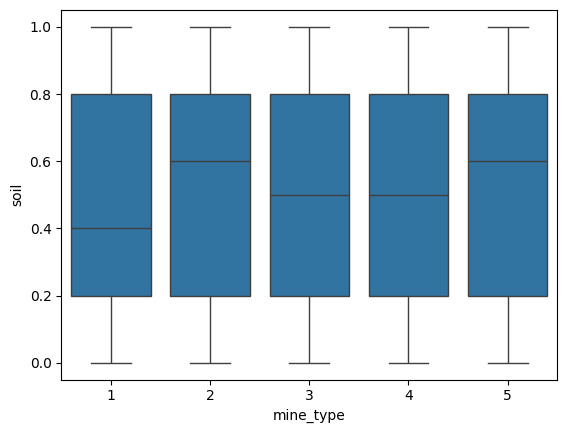

In [9]:
sns.boxplot(x='mine_type', y='soil', data=mine)
plt.show()

In [11]:
mine[['voltage','height','soil']].corr()

,voltage,height,soil
voltage,1.000000,-0.377523,0.070673
height,-0.377523,1.000000,-0.006957
soil,0.070673,-0.006957,1.000000


Part 2

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

x = mine[['voltage', 'height', 'soil']]
y = mine['mine_type']

x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.5, random_state=42, stratify=y
)


Part 3

<Axes: >

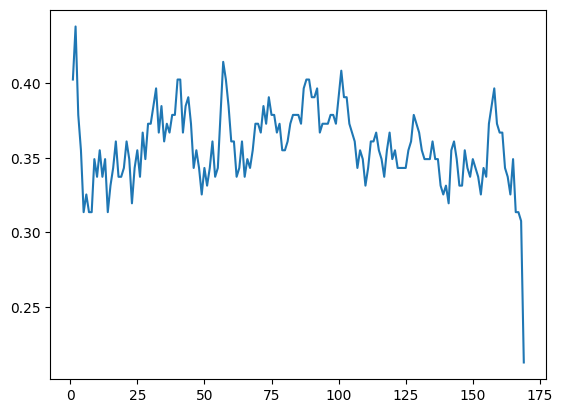

In [29]:
import numpy as np

k_values = range(1, 170)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model = model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)

sns.lineplot(x=k_values, y=accuracies)

I did not exactly select a k value. I wanted to see the accuracy for all the data, so I just made k a range for the sample size.

Part 4

In [31]:
new_k = 60

model = KNeighborsClassifier(n_neighbors=new_k)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

conf_matrix = pd.crosstab( y_test, y_pred, rownames=['Actual'], colnames=['Predicted']
)

print(conf_matrix)

Predicted   1   2  3   4  5
Actual                     
1          18   0  2  11  5
2           0  22  2   6  5
3           9   1  8  11  4
4          11   0  9  10  3
5          15   0  6   8  3


It is not that accurate. Predicting type 2 is the most accurate. The other 4 types were not really accurate at all, especially types 4 and 5.

Part 5

When using this model, it should be used with caution and not as a final decision model. If the model predicts type 2, then this is useful as the mine type is actually likely type 2. If the model predicts any of the other types, it should be still noted and flagged but will not be that useful. If anything, if the model predicts type 4 or 5, that is not very useful information as it is likely wrong.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

Part 1

In [46]:
import pandas as pd

df = pd.read_csv('/content/data/USA_cars_datasets.csv', encoding='latin1')
df.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [48]:
car = df[["price", "year", "mileage"]].copy()
car.shape

(2499, 3)

In [49]:
car.head()

,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [50]:
car.isna().sum()

,0
price,0
year,0
mileage,0


Part 2

In [51]:
car["year"] = (car["year"] - car["year"].min()) / (car["year"].max() - car["year"].min())

In [52]:
car["mileage"] = (car["mileage"] - car["mileage"].min()) / (car["mileage"].max() - car["mileage"].min())

In [53]:
car.head()

,price,year,mileage
0,6300,0.744681,0.269287
1,2899,0.808511,0.187194
2,5350,0.957447,0.038892
3,25000,0.872340,0.063016
4,27700,0.957447,0.006537


Part 3

In [54]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(car, test_size=0.2, random_state=1)

Part 4

In [56]:
x_train = train[["year", "mileage"]].values
y_train = train["price"].values

x_test = test[["year", "mileage"]].values
y_test = test["price"].values

In [62]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

k_values = [3, 10, 25, 50, 100, 300]

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)

k = 3, MSE = 144064589.90111113


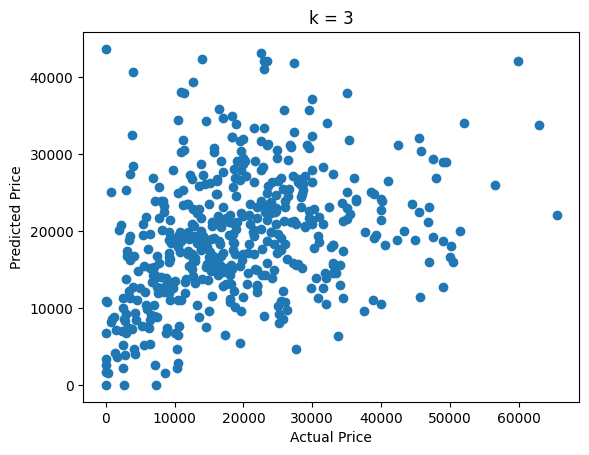

In [64]:
model3 = KNeighborsRegressor(n_neighbors=3)
model3.fit(x_train, y_train)

y_pred3 = model3.predict(x_test)
mse3 = mean_squared_error(y_test, y_pred3)

print("MSE =", mse3)

plt.figure()
plt.scatter(y_test, y_pred3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("k = 3")
plt.show()

MSE = 117051744.24386002


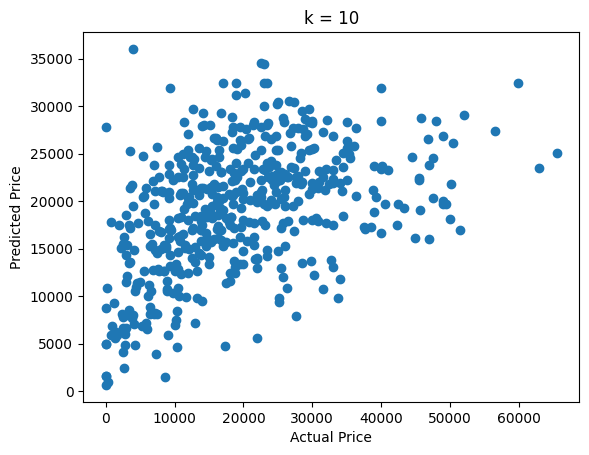

In [71]:
model10 = KNeighborsRegressor(n_neighbors=10)
model10.fit(x_train, y_train)

y_pred10 = model10.predict(x_test)
mse10 = mean_squared_error(y_test, y_pred10)

print("MSE =", mse10)

plt.figure()
plt.scatter(y_test, y_pred10)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("k = 10")
plt.show()

MSE = 108677153.0502048


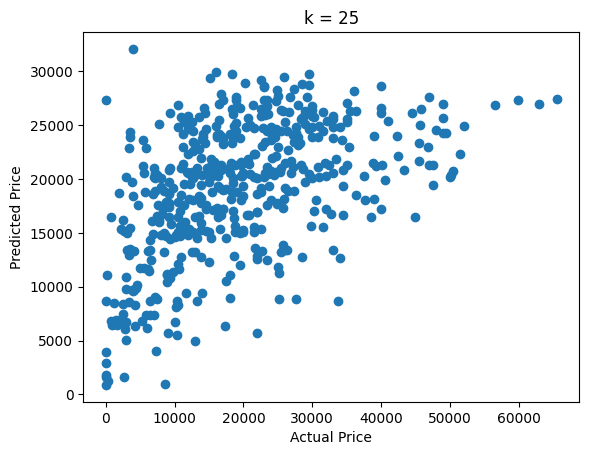

In [72]:
model25 = KNeighborsRegressor(n_neighbors=25)
model25.fit(x_train, y_train)

y_pred25 = model25.predict(x_test)
mse25 = mean_squared_error(y_test, y_pred25)

print("MSE =", mse25)

plt.figure()
plt.scatter(y_test, y_pred25)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("k = 25")
plt.show()

MSE = 107439120.76638879


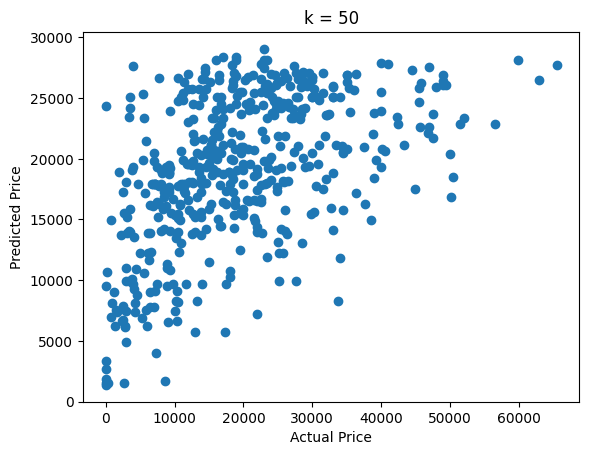

In [75]:
model50 = KNeighborsRegressor(n_neighbors=50)
model50.fit(x_train, y_train)

y_pred50 = model50.predict(x_test)
mse50 = mean_squared_error(y_test, y_pred50)

print("MSE =", mse50)

plt.figure()
plt.scatter(y_test, y_pred50)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("k = 50")
plt.show()

MSE = 107052538.8945762


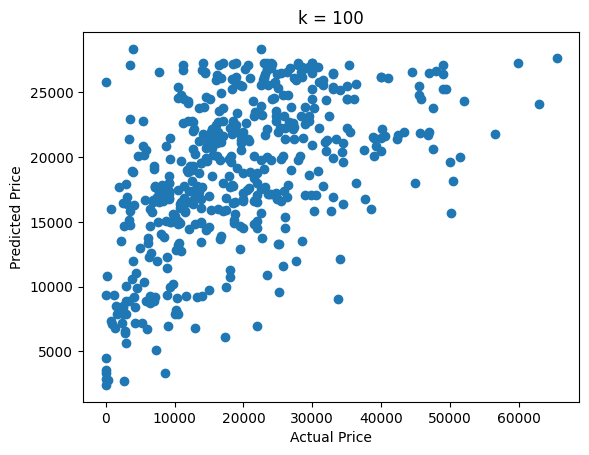

In [76]:
model100 = KNeighborsRegressor(n_neighbors=100)
model100.fit(x_train, y_train)

y_pred100 = model100.predict(x_test)
mse100 = mean_squared_error(y_test, y_pred100)

print("MSE =", mse100)

plt.figure()
plt.scatter(y_test, y_pred100)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("k = 100")
plt.show()

MSE = 109848437.53711972


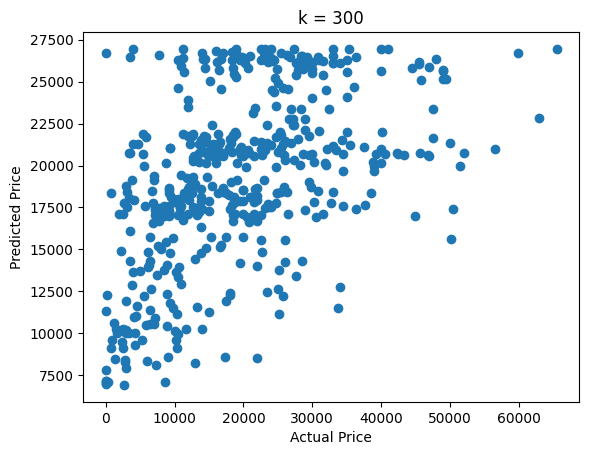

In [77]:
model300 = KNeighborsRegressor(n_neighbors=300)
model300.fit(x_train, y_train)

y_pred300 = model300.predict(x_test)
mse300 = mean_squared_error(y_test, y_pred300)

print("MSE =", mse300)

plt.figure()
plt.scatter(y_test, y_pred300)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("k = 300")
plt.show()

As k increases, the MSE decreases, and the scatterplot looks a little less scattered. This is because, as k increases, there is less variance, and the plots on the scatterplot become more condensed

Part 5. The optimal k value seems to be around 100 based on those past k values. The MSE is lowest at 100 (a k value of 300 had a little higher mse value). The lower the mse value, the less variance and more optimal.

Part 6. When the k value is low, the model tends to overfit due to high variance and high sensitivity to individual values. You also do not want k to be too large (like 300) or else the model will underfit. This is because the prediction will be closer to the mean and will began to ingore the variance in actual prices. So you do not want it too small or too big. Just enough to get the right about of variance.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

Part 1

In [13]:
import pandas as pd

bnb = pd.read_csv('/content/data/airbnb_hw.csv', encoding='latin1')

bnb = bnb.loc[:, ["Review Scores Rating", "Price", "Beds"]]

bnb.head(10)

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0
5,100.0,149,1.0
6,100.0,250,1.0
7,94.0,90,1.0
8,90.0,270,2.0
9,96.0,290,2.0


Part 2

In [14]:
bnb_null = bnb.loc[bnb["Price"].isnull()]
bnb_notnull = bnb.loc[bnb["Review Scores Rating"].notnull()]

print("Missing rows:", bnb_null.shape)
print("Observed rows:", bnb_notnull.shape)

Missing rows: (0, 3)
Observed rows: (22155, 3)


Part 3

In [15]:
bnb_notnull = bnb_notnull.dropna(axis=0, how='any')

Part 4

In [18]:
bnb["Price"] = (
    bnb["Price"].astype(str)
      .str.replace(r"[^0-9.]", "", regex=True))
bnb["Price"] = pd.to_numeric(bnb["Price"], errors="coerce")


In [26]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

bnb_complete = bnb.dropna(axis=0, how="any")

x = bnb_complete[["Price", "Beds"]]
y = bnb_complete["Review Scores Rating"]

x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42
)

k_values = list(range(1, 200))

results = []
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    sse = np.sum((y_test - y_pred) ** 2)
    results.append((k, sse))

results_df = pd.DataFrame(results, columns=["k", "SSE"]).sort_values("SSE")
best_k = int(results_df.iloc[0]["k"])

print("Best k:", best_k)
results_df.head(10)

Best k: 120


,k,SSE
119,120,316709.273750
120,121,316719.758145
121,122,316725.117576
116,117,316751.631456
117,118,316803.234918
87,88,316814.626550
123,124,316830.244277
122,123,316848.603939
80,81,316849.159732
82,83,316850.386558


I chose k by give it a range from 1 to 100. It said 88 was the best k value. Then I increased the range to 200 and it said 120 was the best k value. I increased it again to 300 and it said again that 120 was the best k value, so I stopped increasing the range.

Part 5

In [34]:
bnb_missing = bnb[bnb["Review Scores Rating"].isnull()]
bnb_missing_2 = bnb_missing.dropna(subset=["Price", "Beds"])

x_train_full = bnb_complete[["Price", "Beds"]]
y_train_full = bnb_complete["Review Scores Rating"]

model_predict = KNeighborsRegressor(n_neighbors=120)
model_predict.fit(x_train_full, y_train_full)

x_missing = bnb_missing_2[["Price", "Beds"]]
predicted_ratings = model_predict.predict(x_missing)

df.loc[bnb_missing_2.index, "Review Scores Rating"] = predicted_ratings

predicted_ratings[:10]

array([93.64166667, 88.10833333, 86.70833333, 89.525     , 90.10833333,
       93.91666667, 93.85      , 92.05      , 89.01666667, 91.725     ])

Part 6

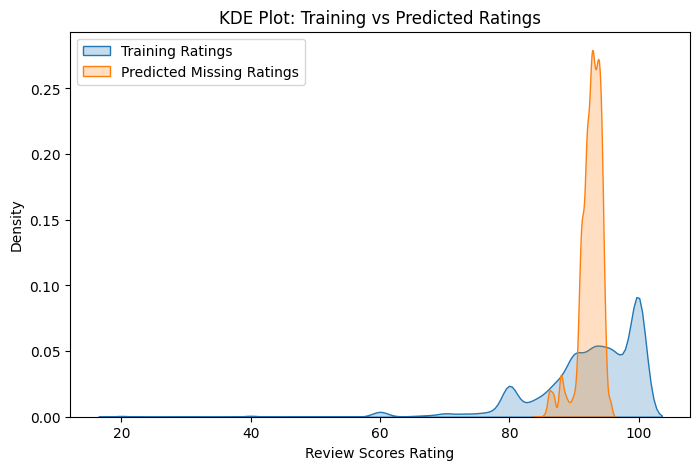

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.kdeplot(y_train_full, label="Training Ratings", fill=True)

sns.kdeplot(predicted_ratings, label="Predicted Missing Ratings", fill=True)

plt.xlabel("Review Scores Rating")
plt.title("KDE Plot: Training vs Predicted Ratings")
plt.legend()
plt.show()

The training ratings are more spreadout, while the predicted missing values are more concentrated around 90. Training ratings peak around 100. They are not similar, but do increase around the same area.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)